<a href="https://colab.research.google.com/github/Danylo5051/machine-learning-practice/blob/main/%D0%A1%D0%B0%D1%82%D0%BA%D0%BE_%D0%94_4_9%D0%9B%D0%912__1__ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Сатко Д. , група 9


---



# Завдання 1

**Був присутній на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [ ]:
import pandas as pd
import requests

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text

tables = pd.read_html(html)    # зчитати всі таблиці
df = tables[2]                 # потрібна таблиця (може змінюватись!), номери не є сталими!
df.head()

/tmp/ipykernel_414/4203454465.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)    # зчитати всі таблиці


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [ ]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [ ]:
df.info

<bound method DataFrame.info of     Country/Territory IMF (2026)[1] World Bank (2025)[6]  \
0               World     126295331            118350166   
1       United States      32383920             30769700   
2          China[n 1]      20851593             19498039   
3             Germany       5452858              5050923   
4               Japan       4379253              4435163   
..                ...           ...                  ...   
217             Palau           377                  345   
218  Marshall Islands           342                  308   
219             Nauru           196                  176   
220        Montserrat          —N/a                 —N/a   
221            Tuvalu            65                   57   

    United Nations (2024)[7]  
0                  111565144  
1                   29298000  
2                   18743802  
3                    4659929  
4                    4026211  
..                       ...  
217                      310  
218                      281  
219                      187  
220                       81  
221                       56  

[222 rows x 4 columns]>

In [ ]:
df.dtypes

,0
Country/Territory,object
IMF (2026)[1],object
World Bank (2025)[6],object
United Nations (2024)[7],object


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [ ]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[\d+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [ ]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


In [ ]:
df['IMF (2026)'] = pd.to_numeric(df['IMF (2026)'], errors='coerce')
df['World Bank (2025)'] = pd.to_numeric(df['World Bank (2025)'], errors='coerce')
df['United Nations (2024)'] = pd.to_numeric(df['United Nations (2024)'], errors='coerce')

In [ ]:
df.dtypes

,0
Country,object
IMF (2026),float64
World Bank (2025),float64
United Nations (2024),float64


In [ ]:
df

,Country,IMF (2026),World Bank (2025),United Nations (2024)
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [ ]:
df.isnull().sum()

,0
Country,0
IMF (2026),31
World Bank (2025),35
United Nations (2024),9


In [ ]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda row: row.fillna(row.mean()), axis=1)

df = df.dropna(subset=df.columns[1:], how='all')

print(df.isnull().sum())

Country                  0
IMF (2026)               0
World Bank (2025)        0
United Nations (2024)    0
dtype: int64


5. Ще раз вивести датасет

In [ ]:
df.tail(10)

,Country,IMF (2026),World Bank (2025),United Nations (2024)
211,Tonga,716.0,679.0,648.0
213,Federated States of Micronesia,521.0,502.0,471.0
214,Anguilla,456.0,456.0,456.0
215,Cook Islands,414.0,414.0,414.0
216,Kiribati,401.0,349.0,343.0
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,81.0,81.0,81.0
221,Tuvalu,65.0,57.0,56.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [ ]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [ ]:
df.describe()

,IMF (2026),World Bank (2025),United Nations (2024)
count,2.130000e+02,2.130000e+02,2.130000e+02
mean,5.943385e+05,5.561409e+05,5.246237e+05
std,2.723652e+06,2.575206e+06,2.455329e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,8.549000e+03,8.840000e+03,8.549000e+03
50%,4.380000e+04,3.960100e+04,3.709400e+04
75%,2.786360e+05,2.640570e+05,2.571450e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [ ]:
df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])

max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'{country} has the largest difference between IMF and WB: {max_diff}')

df.head(10)

United States has the largest difference between IMF and WB: 1614220.0


/tmp/ipykernel_414/29221555.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IMF_WB_Diff'] = abs(df['IMF (2026)'] - df['World Bank (2025)'])


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [ ]:
cor_IMF_WB = df['IMF (2026)'].corr(df['World Bank (2025)'])
cor_IMF_UN = df['IMF (2026)'].corr(df['United Nations (2024)'])
cor_WB_UN = df['World Bank (2025)'].corr(df['United Nations (2024)'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9998772853399375
Correlation between IMF and UN: 0.9998162531253878
Correlation between WB and UN: 0.999860354166563


In [ ]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
    print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
    print('IMF and UN have the highest correlation')
else:
    print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [ ]:
mean_IMF = df['IMF (2026)'].mean()
mean_IMF

np.float64(594338.5211267605)

In [ ]:
mean_WB = df['World Bank (2025)'].mean()
mean_WB

np.float64(556140.9014084507)

In [ ]:
mean_UN = df['United Nations (2024)'].mean()
mean_UN

np.float64(524623.7323943662)

11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [ ]:
df['std'] = df.iloc[:, 1:].std(axis=1)

max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

United States has the highest standard deviation: 13296474.905834844


/tmp/ipykernel_414/4236780574.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['std'] = df.iloc[:, 1:].std(axis=1)


,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.329647e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,8.403818e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.147879e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,1.901140e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.707992e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.735605e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.442251e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.089955e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.083584e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,9.632445e+05


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [ ]:
max_IMF = df['IMF (2026)'].max(); min_IMF = df['IMF (2026)'].min()
max_WB = df['World Bank (2025)'].max(); min_WB = df['World Bank (2025)'].min()
max_UN = df['United Nations (2024)'].max(); min_UN = df['United Nations (2024)'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 32383920.0, Min IMF: 65.0
Max WB: 30769700.0, Min WB: 57.0
Max UN: 29298000.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

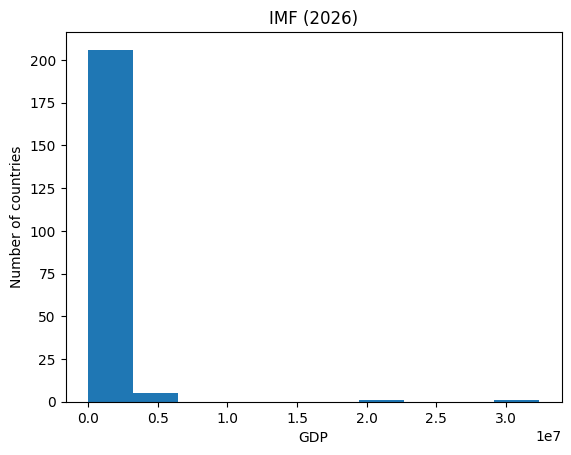

In [ ]:
import matplotlib.pyplot as plt

# Build a histogram of IMF_Forecast
plt.hist(df['IMF (2026)'], bins=10)
plt.title('IMF (2026)')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [ ]:
df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
df['UN_Share'] = df['United Nations (2024)'] / df['United Nations (2024)'].sum()

df.head(10)

/tmp/ipykernel_414/3347587809.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IMF_Share'] = df['IMF (2026)'] / df['IMF (2026)'].sum()
/tmp/ipykernel_414/3347587809.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['WB_Share'] = df['World Bank (2025)'] / df['World Bank (2025)'].sum()
/tmp/ipykernel_414/3347587809.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

,Country,IMF (2026),World Bank (2025),United Nations (2024),IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.329647e+07,0.255809,0.259752,0.262187
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,8.403818e+06,0.164712,0.164599,0.167737
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.147879e+06,0.043074,0.042639,0.041702
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,1.901140e+06,0.034593,0.037441,0.036030
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.707992e+06,0.033689,0.033789,0.032985
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.735605e+06,0.032807,0.033396,0.035368
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.442251e+06,0.028406,0.028418,0.028283
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.089955e+06,0.021629,0.021540,0.021306
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.083584e+06,0.020984,0.021622,0.019450
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,9.632445e+05,0.020822,0.019247,0.019561


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

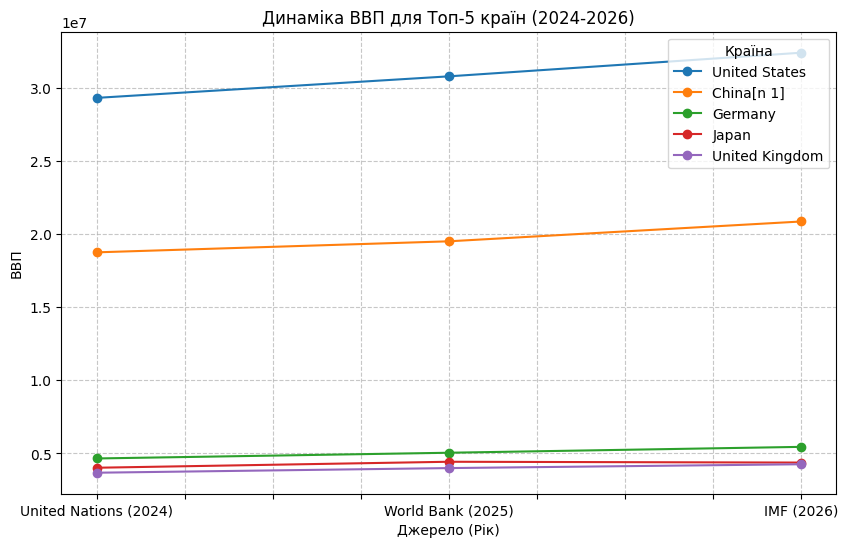

In [ ]:
import matplotlib.pyplot as plt

top5_countries = df.nlargest(5, 'IMF (2026)')

plot_data = top5_countries.set_index('Country')[['United Nations (2024)', 'World Bank (2025)', 'IMF (2026)']]

plot_data = plot_data.T

plot_data.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Динаміка ВВП для Топ-5 країн (2024-2026)')
plt.xlabel('Джерело (Рік)')
plt.ylabel('ВВП')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Країна')
plt.show()